In [14]:
# Install required libraries
%pip install pygeohash

# Import libraries
import pandas as pd
import numpy as np
import pygeohash as gh
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.spatial import distance_matrix
import networkx as nx
import time

In [15]:
# Initialize an empty DataFrame
Chicago = pd.DataFrame()

# Import all available Chicago files
for i in range(1, 20):
    file_link = f'https://raw.githubusercontent.com/IsamAljawarneh/datasets/refs/heads/master/data/Chicago/AQ_data/chicago_eclipse_data_part_{i}.csv'
    temp_df = pd.read_csv(file_link, index_col=False)
    Chicago = pd.concat([Chicago, temp_df], ignore_index=True)

# Check for required columns
required_columns = ['Latitude', 'Longitude', 'PM25']
if not all(col in Chicago.columns for col in required_columns):
    raise ValueError(f"Missing required columns: {set(required_columns) - set(Chicago.columns)}")

# Remove rows with missing or invalid data
Chicago = Chicago.dropna(subset=required_columns)

# Remove outliers in PM25 using the IQR method
q1 = Chicago['PM25'].quantile(0.25)
q3 = Chicago['PM25'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
Chicago = Chicago[(Chicago['PM25'] >= lower_bound) & (Chicago['PM25'] <= upper_bound)]

# Display the cleaned dataset
print(f"Dataset size after cleaning: {Chicago.shape}")
Chicago.head()

Dataset size after cleaning: (2330547, 16)


,City,DeviceId,LocationName,Latitude,Longitude,ReadingDateTimeUTC,PM25,CalibratedPM25,CalibratedO3,CalibratedNO2,CO,Temperature,Humidity,BatteryLevel,PercentBattery,CellSignal
0,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-20 00:03:00,5.561094,NaN,NaN,NaN,0.123580,27.383499,55.128479,4.237187,93.964844,-76.0
1,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-20 00:08:10,6.633914,NaN,NaN,NaN,0.132103,27.079086,55.059814,4.236094,93.964844,-81.0
2,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-20 00:13:20,4.068707,NaN,NaN,NaN,0.131126,27.079086,55.035400,4.236406,93.964844,-80.0
3,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-20 00:18:30,6.351702,NaN,NaN,NaN,0.138784,26.945572,54.632568,4.236094,93.863281,-82.0
4,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-20 00:23:40,9.574065,NaN,NaN,NaN,0.413070,26.828079,53.907776,4.235938,93.863281,-81.0


In [16]:
# Add Geohash grouping based on latitude and longitude
Geohash_precision = 6
Chicago["GeoHash Code"] = Chicago.apply(lambda x: gh.encode(x.Latitude, x.Longitude, precision=Geohash_precision), axis=1)

# Display the dataset with Geohash codes
Chicago.head()

,City,DeviceId,LocationName,Latitude,Longitude,ReadingDateTimeUTC,PM25,CalibratedPM25,CalibratedO3,CalibratedNO2,CO,Temperature,Humidity,BatteryLevel,PercentBattery,CellSignal,GeoHash Code
0,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-20 00:03:00,5.561094,NaN,NaN,NaN,0.123580,27.383499,55.128479,4.237187,93.964844,-76.0,dp3ty0
1,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-20 00:08:10,6.633914,NaN,NaN,NaN,0.132103,27.079086,55.059814,4.236094,93.964844,-81.0,dp3ty0
2,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-20 00:13:20,4.068707,NaN,NaN,NaN,0.131126,27.079086,55.035400,4.236406,93.964844,-80.0,dp3ty0
3,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-20 00:18:30,6.351702,NaN,NaN,NaN,0.138784,26.945572,54.632568,4.236094,93.863281,-82.0,dp3ty0
4,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-20 00:23:40,9.574065,NaN,NaN,NaN,0.413070,26.828079,53.907776,4.235938,93.863281,-81.0,dp3ty0


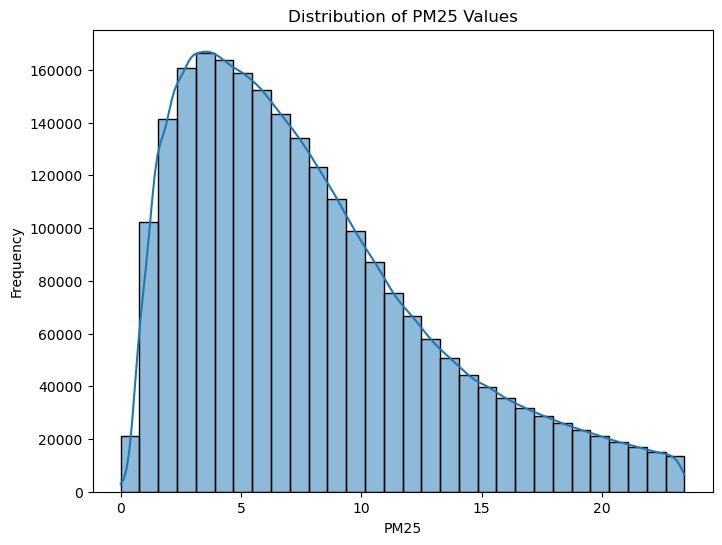

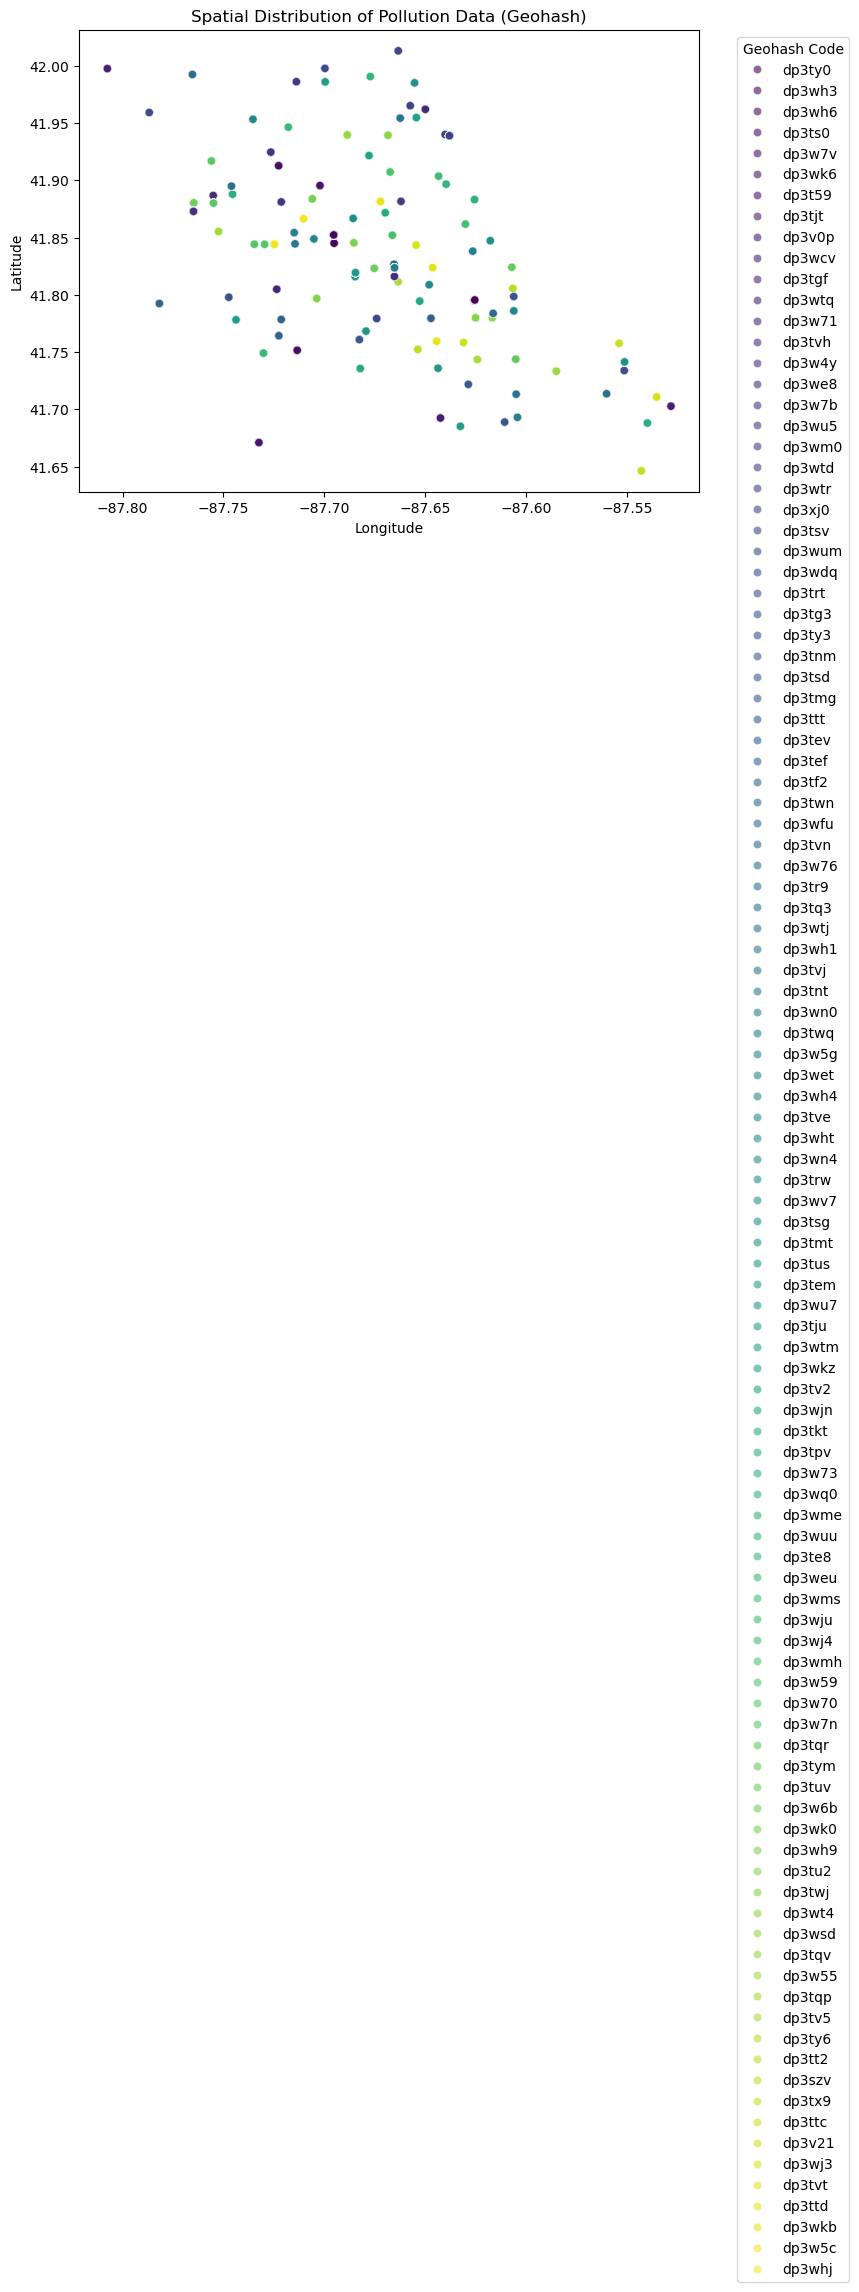

In [17]:
# Histogram of PM25 values
plt.figure(figsize=(8, 6))
sns.histplot(Chicago['PM25'], bins=30, kde=True)
plt.title('Distribution of PM25 Values')
plt.xlabel('PM25')
plt.ylabel('Frequency')
plt.show()

# Scatter plot of geohash-based spatial data
plt.figure(figsize=(8, 6))
sns.scatterplot(data=Chicago, x='Longitude', y='Latitude', hue='GeoHash Code', palette='viridis', alpha=0.6)
plt.title('Spatial Distribution of Pollution Data (Geohash)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Geohash Code', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

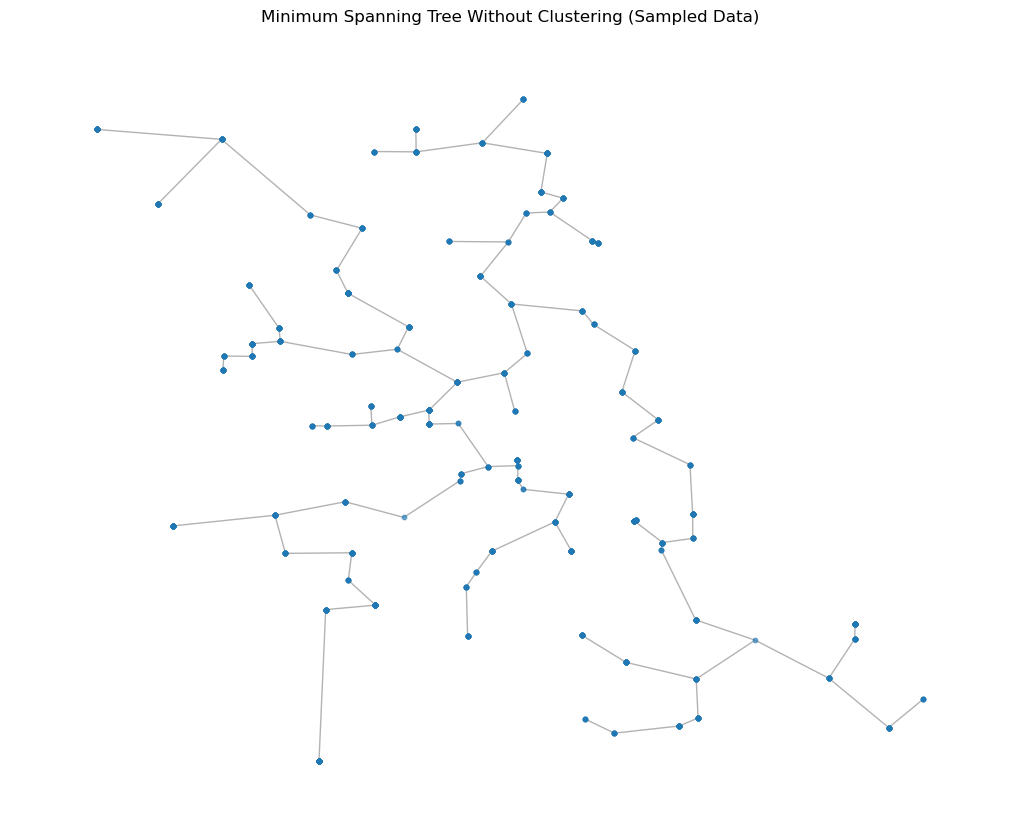

In [18]:
# Sample 1000 points for testing (adjust as needed)
sample_size = 1000
if len(Chicago) > sample_size:
    Chicago_sample = Chicago.sample(n=sample_size, random_state=42)
else:
    Chicago_sample = Chicago

# Create a distance matrix for the sampled points
dist_matrix_full = distance_matrix(Chicago_sample[['Latitude', 'Longitude']], Chicago_sample[['Latitude', 'Longitude']])

# Create a graph and add edges with weights
G_full = nx.Graph()
for i in range(len(Chicago_sample)):
    for j in range(i + 1, len(Chicago_sample)):
        G_full.add_edge(i, j, weight=dist_matrix_full[i, j])

# Generate the MST
mst_full = nx.minimum_spanning_tree(G_full)

# Visualize the MST
pos_full = {i: (Chicago_sample.iloc[i]['Longitude'], Chicago_sample.iloc[i]['Latitude']) for i in range(len(Chicago_sample))}
plt.figure(figsize=(10, 8))
nx.draw(mst_full, pos_full, node_size=10, edge_color='gray', alpha=0.6)
plt.title('Minimum Spanning Tree Without Clustering (Sampled Data)')
plt.show()

c:\Users\ohood\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


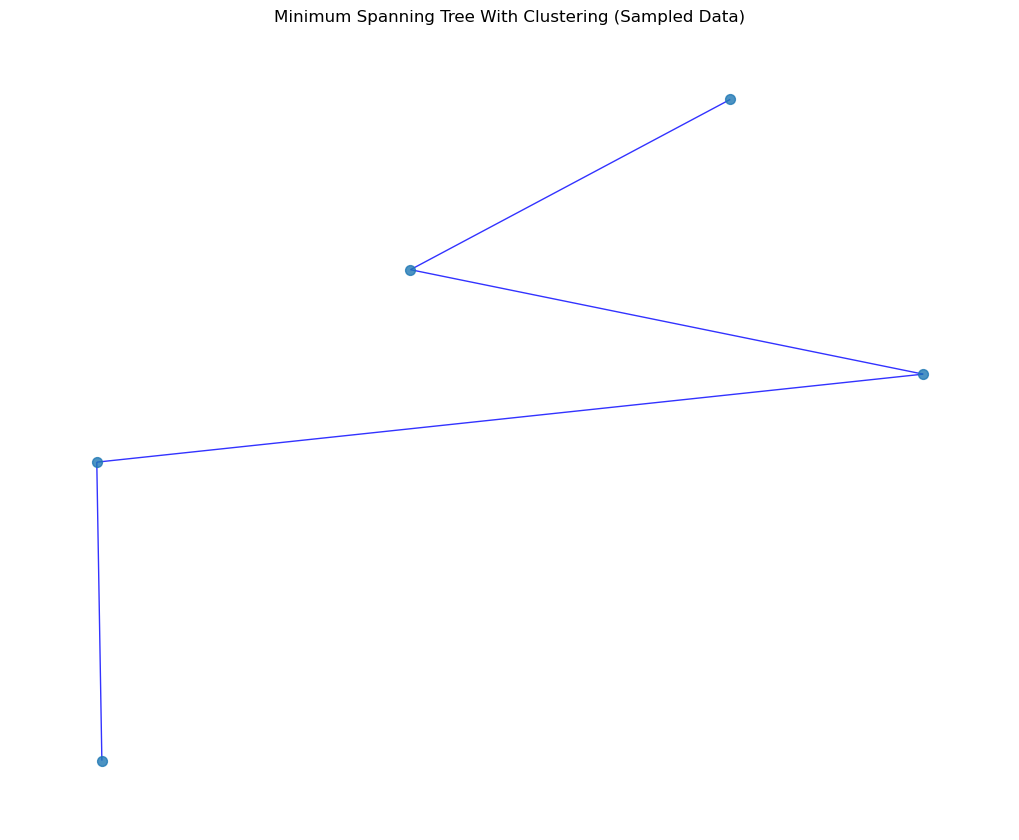

In [19]:
# Perform K-means clustering on the sampled points
kmeans = KMeans(n_clusters=5, random_state=42)  # Adjust n_clusters as needed
Chicago_sample['Cluster'] = kmeans.fit_predict(Chicago_sample[['Latitude', 'Longitude', 'PM25']])

# Calculate centroids for each cluster
centroids = Chicago_sample.groupby('Cluster').agg({
    'Latitude': 'mean',
    'Longitude': 'mean',
    'PM25': 'mean'
}).reset_index()

# Create a distance matrix for centroids
dist_matrix_centroids = distance_matrix(centroids[['Latitude', 'Longitude']], centroids[['Latitude', 'Longitude']])

# Create a graph and add edges with weights
G_centroids = nx.Graph()
for i in range(len(centroids)):
    for j in range(i + 1, len(centroids)):
        G_centroids.add_edge(i, j, weight=dist_matrix_centroids[i, j])

# Generate the MST
mst_centroids = nx.minimum_spanning_tree(G_centroids)

# Visualize the MST
pos_centroids = {i: (centroids.iloc[i]['Longitude'], centroids.iloc[i]['Latitude']) for i in range(len(centroids))}
plt.figure(figsize=(10, 8))
nx.draw(mst_centroids, pos_centroids, node_size=50, edge_color='blue', alpha=0.8)
plt.title('Minimum Spanning Tree With Clustering (Sampled Data)')
plt.show()

Time without clustering: 2.62 seconds
Time with clustering: 0.00 seconds


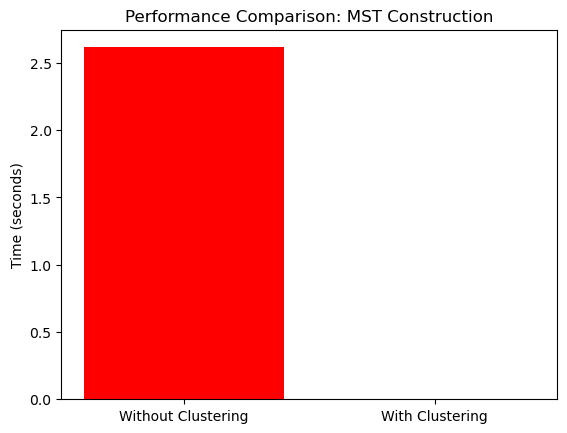

In [20]:
# Measure time for MST without clustering
start_time = time.time()
mst_full = nx.minimum_spanning_tree(G_full)
time_without_clustering = time.time() - start_time

# Measure time for MST with clustering
start_time = time.time()
mst_centroids = nx.minimum_spanning_tree(G_centroids)
time_with_clustering = time.time() - start_time

# Print the results
print(f"Time without clustering: {time_without_clustering:.2f} seconds")
print(f"Time with clustering: {time_with_clustering:.2f} seconds")

# Plot comparison
plt.bar(['Without Clustering', 'With Clustering'], [time_without_clustering, time_with_clustering], color=['red', 'blue'])
plt.ylabel('Time (seconds)')
plt.title('Performance Comparison: MST Construction')
plt.show()

In [21]:
# Calculate RMSE for MST without clustering
rmse_without_clustering = np.sqrt(np.mean(dist_matrix_full**2))

# Calculate RMSE for MST with clustering
rmse_with_clustering = np.sqrt(np.mean(dist_matrix_centroids**2))

# Print the results
print(f"RMSE without clustering: {rmse_without_clustering:.2f}")
print(f"RMSE with clustering: {rmse_with_clustering:.2f}")

RMSE without clustering: 0.15
RMSE with clustering: 0.01
